In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('AB_NYC_2019.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [6]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [7]:
df['reviews_per_month']=df['reviews_per_month'].fillna(0)

In [8]:
df.dropna(subset=['name','host_name'],inplace=True)

In [9]:
df['last_review']=df['last_review'].fillna('No Reviews')

In [10]:
df=df[df['price']>0]

In [11]:
df.drop(['id','host_id'],axis=1,inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

C:\Users\manas\AppData\Local\Temp\ipykernel_5284\3556578746.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df,x='neighbourhood_group',palette='rocket', order=df['neighbourhood_group'].value_counts().index)


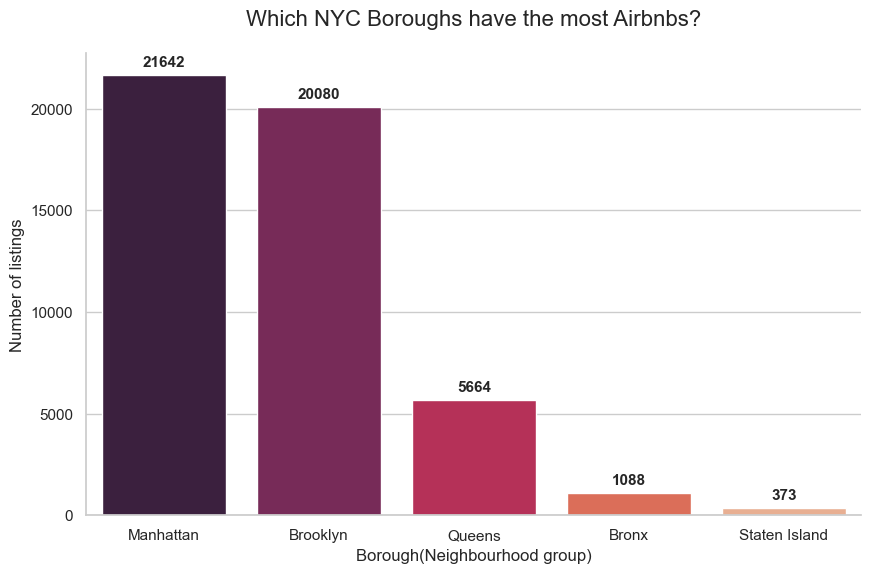

In [13]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(10,6))

ax=sns.countplot(data=df,x='neighbourhood_group',palette='rocket', order=df['neighbourhood_group'].value_counts().index)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.title('Which NYC Boroughs have the most Airbnbs?',fontsize=16,pad=20)
plt.xlabel('Borough(Neighbourhood group)',fontsize=12)
plt.ylabel('Number of listings',fontsize=12)

sns.despine()
plt.show()

C:\Users\manas\AppData\Local\Temp\ipykernel_5284\2736717997.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=affordable,x='neighbourhood_group',y='price',palette='plasma')


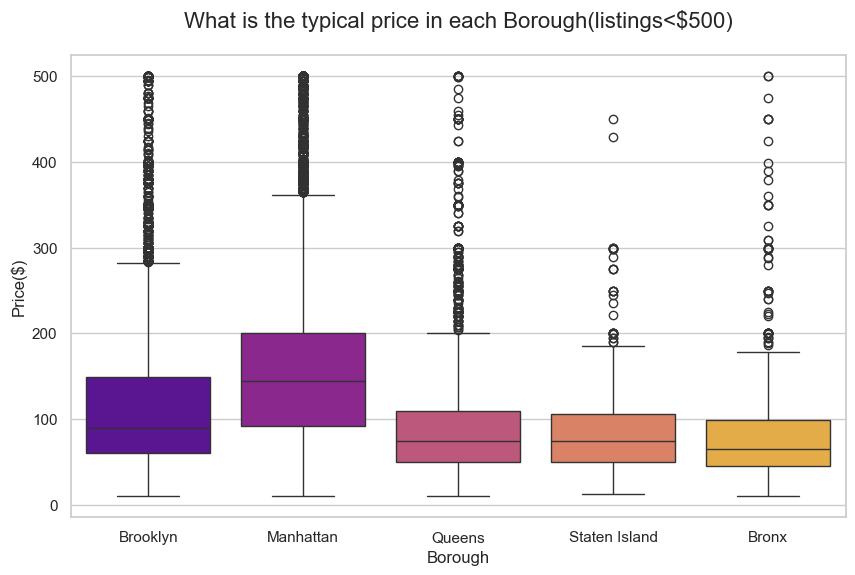

In [14]:
affordable=df[df['price']<=500]

plt.figure(figsize=(10,6))
sns.boxplot(data=affordable,x='neighbourhood_group',y='price',palette='plasma')

plt.title('What is the typical price in each Borough(listings<$500)',fontsize=16,pad=20)
plt.xlabel('Borough',fontsize=12)
plt.ylabel('Price($)',fontsize=12)
plt.show()

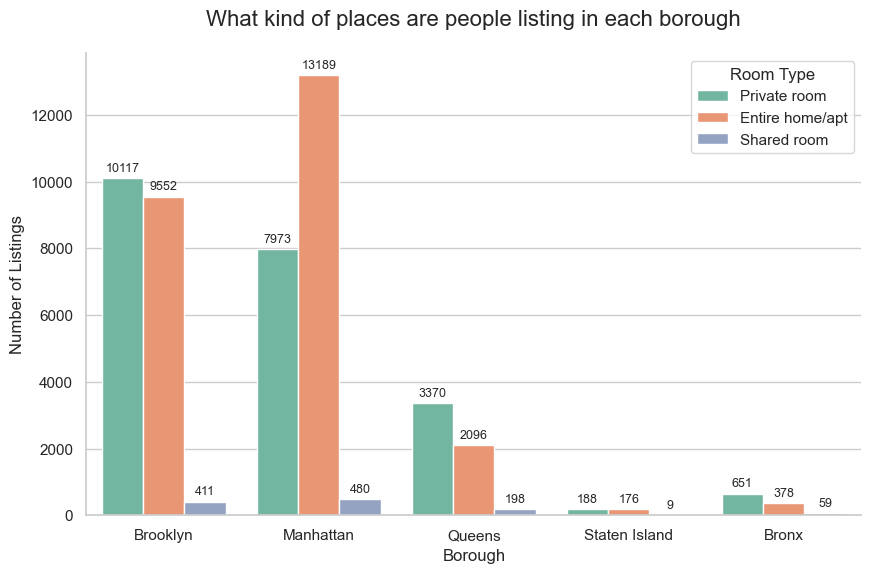

In [15]:
plt.figure(figsize=(10,6))
ax=sns.countplot(data=df,x='neighbourhood_group',hue='room_type',palette='Set2')

for p in ax.patches:
    if p.get_height() > 0: # Only label bars that actually have data
        ax.annotate(f'{int(p.get_height())}', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='center', 
            xytext=(0, 7), 
            textcoords='offset points',
            fontsize=9)

plt.title('What kind of places are people listing in each borough',fontsize=16,pad=20)
plt.xlabel('Borough',fontsize=12)
plt.ylabel('Number of Listings',fontsize=12)
plt.legend(title='Room Type')

sns.despine()
plt.show()

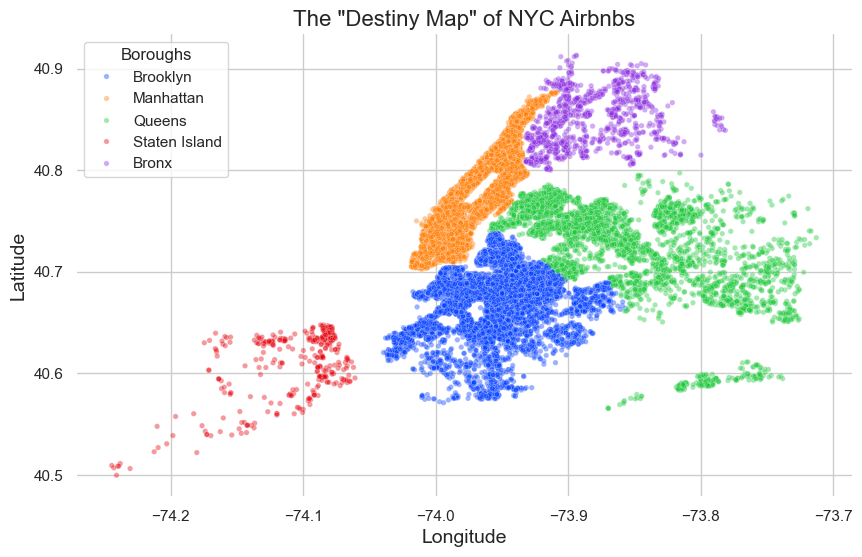

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,x='longitude',y='latitude',hue='neighbourhood_group',palette='bright',s=15,alpha=0.4)

plt.title('The "Destiny Map" of NYC Airbnbs',fontsize=16)
plt.xlabel('Longitude',fontsize=14)
plt.ylabel('Latitude',fontsize=14)
plt.legend(title='Boroughs')

sns.despine(left=True,bottom=True)
plt.show()

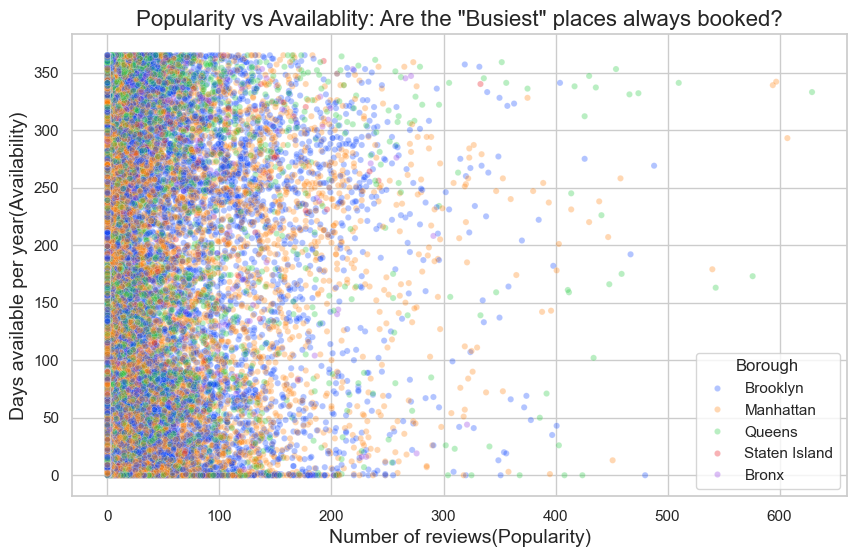

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,x='number_of_reviews',y='availability_365',hue='neighbourhood_group',palette='bright',s=20,alpha=0.3)

plt.title('Popularity vs Availablity: Are the "Busiest" places always booked?',fontsize=16)
plt.xlabel('Number of reviews(Popularity)',fontsize=14)
plt.ylabel('Days available per year(Availability)',fontsize=14)
plt.legend(title='Borough')
plt.show()

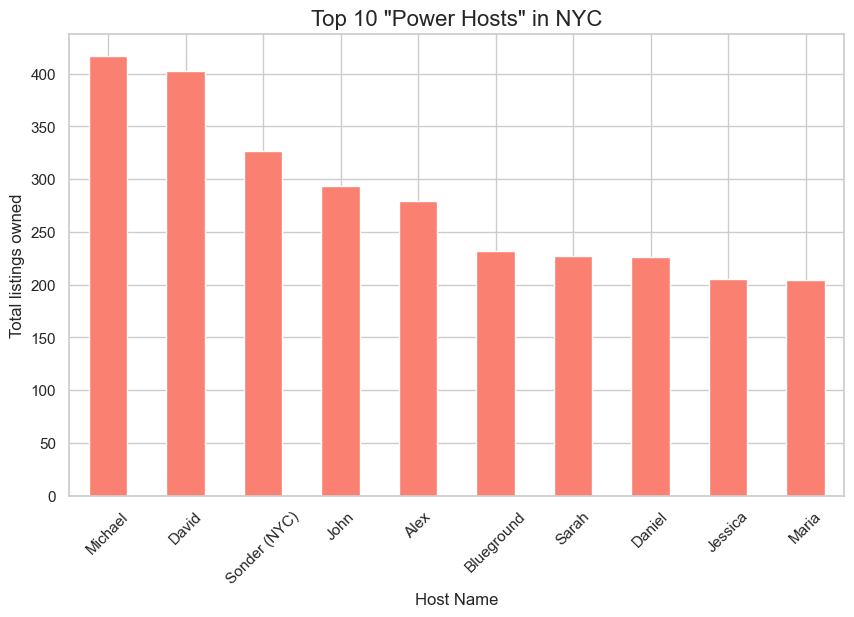

In [18]:
top_hosts=df['host_name'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_hosts.plot(kind='bar',color='salmon')

plt.title('Top 10 "Power Hosts" in NYC',fontsize=16)
plt.xlabel('Host Name',fontsize=12)
plt.ylabel('Total listings owned',fontsize=12)
plt.xticks(rotation=45)
plt.show()

C:\Users\manas\AppData\Local\Temp\ipykernel_5284\3168114679.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


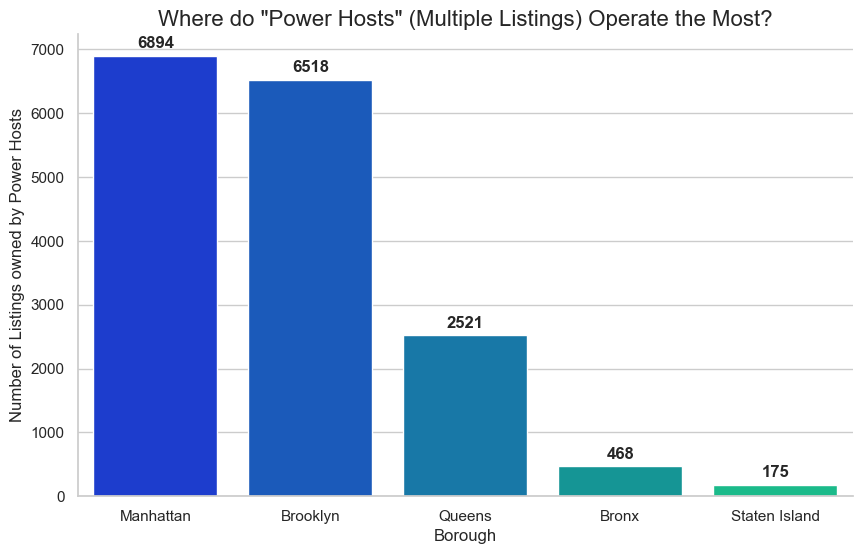

In [19]:
power_hosts_df = df[df['calculated_host_listings_count'] > 1]

plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=power_hosts_df, 
    x='neighbourhood_group', 
    palette='winter', 
    order=power_hosts_df['neighbourhood_group'].value_counts().index
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontweight='bold')

plt.title('Where do "Power Hosts" (Multiple Listings) Operate the Most?', fontsize=16)
plt.xlabel('Borough')
plt.ylabel('Number of Listings owned by Power Hosts')
sns.despine()
plt.show()

C:\Users\manas\AppData\Local\Temp\ipykernel_5284\1216326178.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


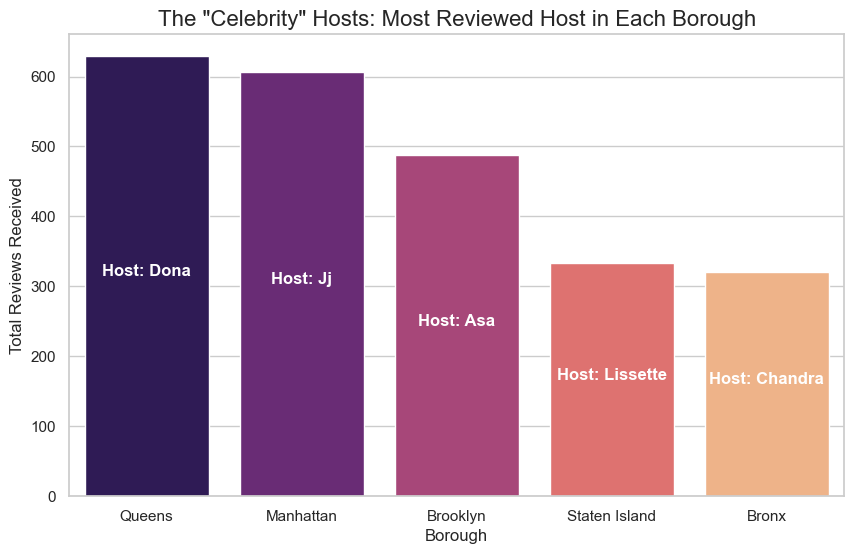

In [20]:
best_hosts = df.sort_values('number_of_reviews', ascending=False).drop_duplicates('neighbourhood_group')

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=best_hosts, 
    x='neighbourhood_group', 
    y='number_of_reviews', 
    palette='magma'
)

for i, row in enumerate(best_hosts.itertuples()):
    ax.text(i, row.number_of_reviews/2, f"Host: {row.host_name}", 
            color='white', ha="center", weight='bold', fontsize=12)

plt.title('The "Celebrity" Hosts: Most Reviewed Host in Each Borough', fontsize=16)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Total Reviews Received', fontsize=12)
plt.show()

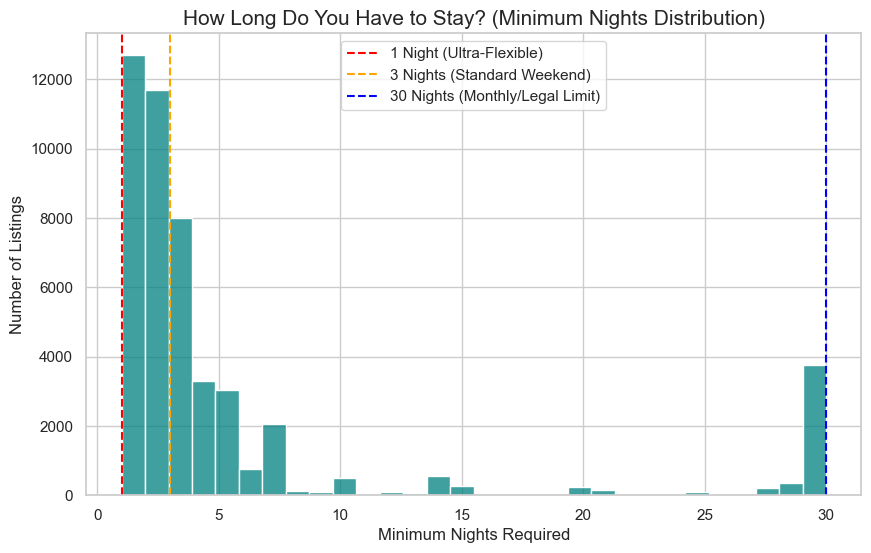

In [21]:
plt.figure(figsize=(10,6))

short_stay=df[df['minimum_nights']<=30]

sns.histplot(short_stay['minimum_nights'],bins=30,color='teal',kde=False)

plt.title('How Long Do You Have to Stay? (Minimum Nights Distribution)', fontsize=15)
plt.xlabel('Minimum Nights Required', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)

plt.axvline(x=1, color='red', linestyle='--', label='1 Night (Ultra-Flexible)')
plt.axvline(x=3, color='orange', linestyle='--', label='3 Nights (Standard Weekend)')
plt.axvline(x=30, color='blue', linestyle='--', label='30 Nights (Monthly/Legal Limit)')

plt.legend()
plt.show()

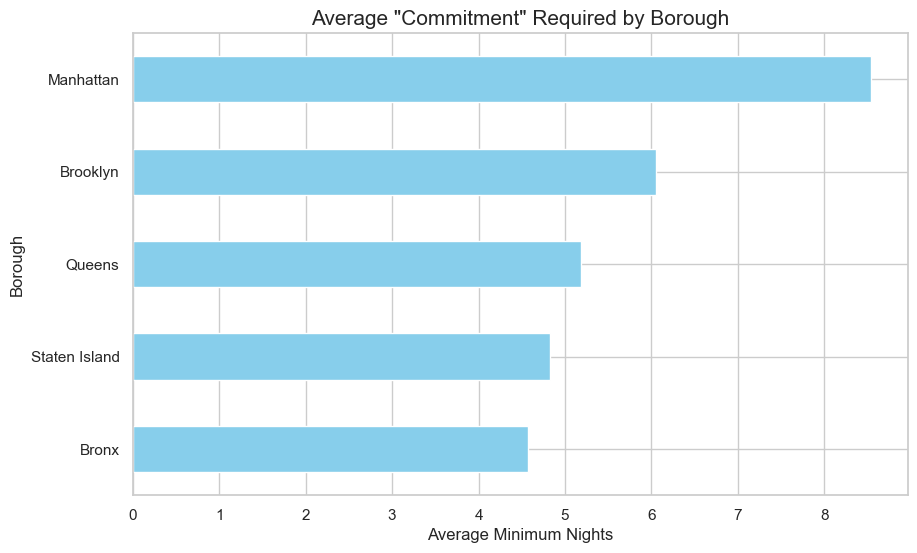

In [22]:
avg_min_nights = df.groupby('neighbourhood_group')['minimum_nights'].mean().sort_values()

plt.figure(figsize=(10, 6))
avg_min_nights.plot(kind='barh', color='skyblue')

plt.title('Average "Commitment" Required by Borough', fontsize=15)
plt.xlabel('Average Minimum Nights')
plt.ylabel('Borough')
plt.show()

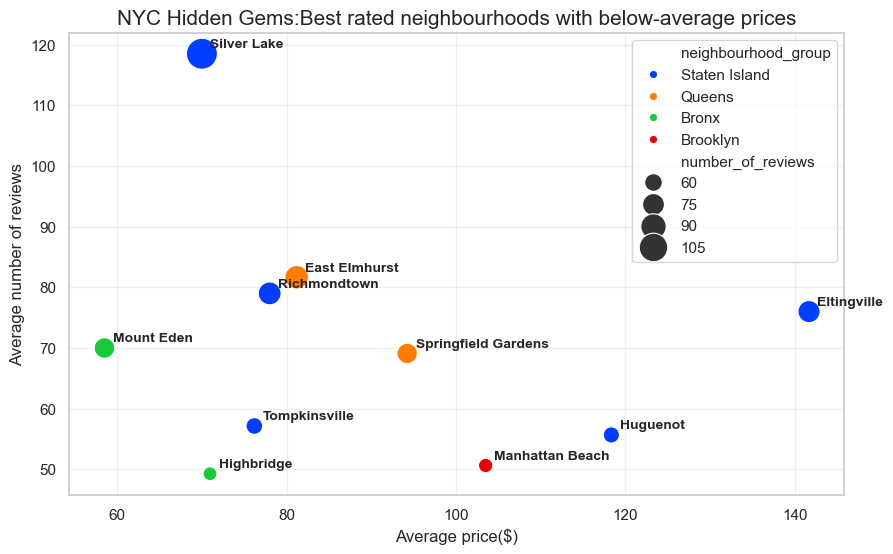

In [24]:
vfm_df=df.groupby(['neighbourhood_group','neighbourhood']).agg({
    'price':'mean',
    'number_of_reviews':'mean'
}).reset_index()

city_avg_price=df['price'].mean()
city_avg_reviews=df['number_of_reviews'].mean()

gems=vfm_df[(vfm_df['price']<city_avg_price) & (vfm_df['number_of_reviews']>city_avg_reviews)]
top_gems=gems.sort_values(by='number_of_reviews',ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.scatterplot(data=top_gems,x='price',y='number_of_reviews',hue='neighbourhood_group',size='number_of_reviews',sizes=(100,500),palette='bright')

for i in range(top_gems.shape[0]):
    plt.text(top_gems.price.iloc[i]+1, top_gems.number_of_reviews.iloc[i]+1, 
             top_gems.neighbourhood.iloc[i], fontsize=10, weight='semibold')

plt.title('NYC Hidden Gems:Best rated neighbourhoods with below-average prices',fontsize=15)
plt.xlabel('Average price($)')
plt.ylabel('Average number of reviews')
plt.grid(True,alpha=0.3)

plt.show()

C:\Users\manas\AppData\Local\Temp\ipykernel_5284\721678204.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x=percentage_red_flag.index,y=percentage_red_flag.values,palette='Reds_r')


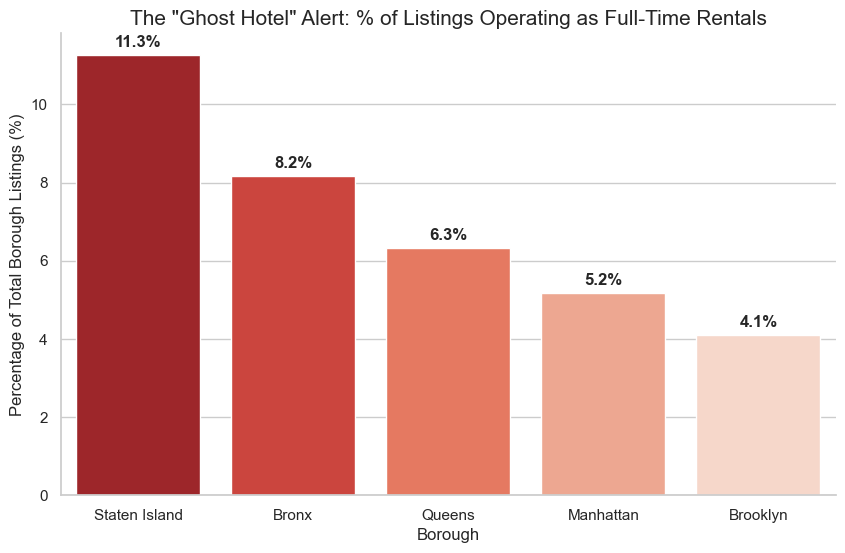

In [28]:
red_flag_df=df[
    (df['room_type']=='Entire home/apt') &
    (df['availability_365']>300) &
    (df['minimum_nights']<30)
]

total_listings=df['neighbourhood_group'].value_counts()
red_flag_listings=red_flag_df['neighbourhood_group'].value_counts()
percentage_red_flag=(red_flag_listings/total_listings*100).fillna(0).sort_values(ascending=False)

plt.figure(figsize=(10,6))
ax=sns.barplot(x=percentage_red_flag.index,y=percentage_red_flag.values,palette='Reds_r')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontweight='bold')

plt.title('The "Ghost Hotel" Alert: % of Listings Operating as Full-Time Rentals', fontsize=15)
plt.ylabel('Percentage of Total Borough Listings (%)')
plt.xlabel('Borough')

sns.despine()
plt.show()